# Phase 3 training visualizations

Use this notebook **after** a run finishes (or while it is still writing logs).

**What it does**
- Loads the latest `*.log.json` under your MMDet `work_dir` (same format as `tools/plot_workdir_train_curves.py`).
- Plots `loss_ttc`, total `loss`, `grad_norm`, and learning rate vs iteration.
- Optionally shows a sample **BEV / panel** PNG if you generated one with `tools/visualize_ttc_bev.py` or the Slurm `RUN_TTC_BEV=1` step.

**Optional — MLP vs baseline:** last section runs `tools/eval_ttc_mlp.py` (needs GPU, same conda env as training).

**Requirements:** `matplotlib`, `numpy` (and `IPython` in Jupyter). Set `WORK_DIR` below to your run directory.

In [5]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# --- edit this to your MMDet work directory (contains *.log.json) ---
WORK_DIR = Path("../work_dirs/streampetr_ttc_frozen_20e")  # or: streampetr_ttc_frozen_20e

# Optional: folder with BEV outputs (*_ttc_panel.png) from visualize_ttc_bev.py
BEV_DIR = WORK_DIR / "ttc_bev_gt"

SMOOTH_WIN = 50  # rolling mean window (0 = no smoothing)

In [6]:
def load_train_rows(work_dir: Path):
    logs = sorted(work_dir.glob("*.log.json"), key=lambda p: p.stat().st_mtime)
    if not logs:
        raise FileNotFoundError(f"No *.log.json under {work_dir.resolve()}")
    log_path = logs[-1]
    rows = []
    with open(log_path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    train = [r for r in rows if r.get("mode") == "train"]
    if not train:
        raise ValueError(f"No train rows in {log_path}")
    return train, log_path


def rolling_mean(y: np.ndarray, win: int) -> np.ndarray:
    if win <= 1 or len(y) < win:
        return y.astype(float)
    y = y.astype(float)
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    k = np.ones(win) / win
    return np.convolve(yp, k, mode="valid")[: len(y)]


train_rows, LOG_PATH = load_train_rows(WORK_DIR)
iters = np.array([r.get("iter", i) for i, r in enumerate(train_rows)])
print(f"Loaded {len(train_rows)} train rows from:\n  {LOG_PATH.resolve()}")

Loaded 554 train rows from:
  /hpc/group/naderilab/eb408/CS372/StreamPETR/work_dirs/streampetr_ttc_frozen_20e/20260409_141401.log.json


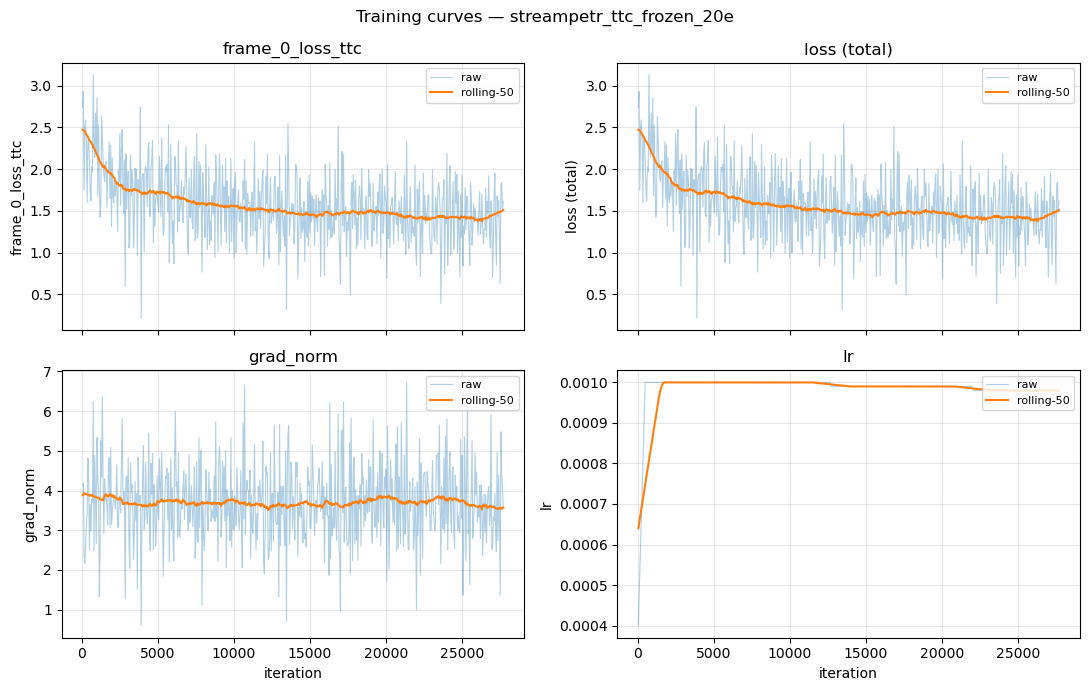

In [7]:
def series(key: str) -> np.ndarray:
    out = []
    for r in train_rows:
        v = r.get(key)
        if v is None:
            out.append(np.nan)
        else:
            try:
                out.append(float(v))
            except (TypeError, ValueError):
                out.append(np.nan)
    return np.array(out, dtype=float)


keys_to_plot = [
    ("frame_0_loss_ttc", "frame_0_loss_ttc"),
    ("loss", "loss (total)"),
    ("grad_norm", "grad_norm"),
    ("lr", "lr"),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
axes = axes.ravel()

for ax, (key, title) in zip(axes, keys_to_plot):
    y = series(key)
    if np.all(np.isnan(y)):
        ax.set_title(f"{title} — missing in log")
        continue
    ax.plot(iters, y, alpha=0.35, linewidth=0.8, label="raw")
    if SMOOTH_WIN > 1:
        ys = rolling_mean(np.nan_to_num(y, nan=np.nanmedian(y)), SMOOTH_WIN)
        ax.plot(iters, ys, linewidth=1.5, label=f"rolling-{SMOOTH_WIN}")
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right", fontsize=8)

axes[-2].set_xlabel("iteration")
axes[-1].set_xlabel("iteration")
fig.suptitle(f"Training curves — {WORK_DIR.name}", fontsize=12)
fig.tight_layout()
plt.show()

### Optional: sample BEV / camera panel

If `BEV_DIR` exists and contains `*_ttc_panel.png` (from `visualize_ttc_bev.py`), the next cell displays one image.

In [8]:
from IPython.display import Image, display

bev_pngs = sorted(BEV_DIR.glob("*_ttc_panel.png")) if BEV_DIR.is_dir() else []
if not bev_pngs:
    print(f"No *_ttc_panel.png under {BEV_DIR} — skip BEV (or run visualize_ttc_bev.py).")
else:
    sample = bev_pngs[len(bev_pngs) // 2]
    print(f"Showing: {sample.name} ({len(bev_pngs)} panels total)")
    display(Image(filename=str(sample), width=900))

No *_ttc_panel.png under ../work_dirs/streampetr_ttc_frozen_20e/ttc_bev_gt — skip BEV (or run visualize_ttc_bev.py).


### Does the TTC MLP help? (val loss vs pretrained baseline)

`tools/test.py` **does not** run the TTC head, so it cannot score TTC directly. Use **`tools/eval_ttc_mlp.py`**: it runs the **same `loss_ttc` forward** as training on a chosen split (e.g. **val** infos) and reports the mean **sum of `frame_*_loss_ttc` per batch**.

- **Trained checkpoint** — after Phase 3 `iter_*.pth`.
- **`--pretrained-baseline`** — same StreamPETR weights as `load_from`; TTC head layers stay **random** if that checkpoint has no `ttc_head` keys.

**Lower** mean loss on the same split / batch count ⇒ MLP fits GT TTC better than the baseline. This is **not** the same as `ttc_heuristic_baseline.py` (geometry heuristic from boxes).

Edit paths in the next cell, then run it (needs GPU + repo env).

In [9]:
import os
import subprocess
import sys
from pathlib import Path

# If the notebook lives in notebooks/, repo root is one level up.
REPO_ROOT = Path("..").resolve()
if not (REPO_ROOT / "tools" / "eval_ttc_mlp.py").is_file():
    REPO_ROOT = Path.cwd()

CONFIG = REPO_ROOT / "projects/configs/StreamPETR/stream_petr_vov_ttc_frozen_20e.py"
TRAINED_CKPT = REPO_ROOT / "work_dirs/streampetr_ttc_frozen_20e/iter_281300.pth"  # set to your latest .pth
PRETRAINED = REPO_ROOT / "ckpts/stream_petr_vov_flash_800_bs2_seq_24e.pth"
ANN_VAL = REPO_ROOT / "data/nuscenes/nuscenes2d_temporal_infos_val.pkl"
MAX_BATCHES = 80

cmd = [
    sys.executable,
    str(REPO_ROOT / "tools/eval_ttc_mlp.py"),
    str(CONFIG),
    str(TRAINED_CKPT),
    "--ann-file",
    str(ANN_VAL),
    "--pretrained-baseline",
    str(PRETRAINED),
    "--max-batches",
    str(MAX_BATCHES),
    "--gpu-id",
    "0",
]
print("Running:\n ", " ".join(cmd))
os.chdir(REPO_ROOT)
proc = subprocess.run(cmd, capture_output=True, text=True)
print(proc.stdout)
if proc.stderr:
    print(proc.stderr, file=sys.stderr)
if proc.returncode != 0:
    raise RuntimeError(f"eval_ttc_mlp.py exited with {proc.returncode}")

Running:
  /opt/conda/envs/rapids/bin/python /hpc/group/naderilab/eb408/CS372/StreamPETR/tools/eval_ttc_mlp.py /hpc/group/naderilab/eb408/CS372/StreamPETR/projects/configs/StreamPETR/stream_petr_vov_ttc_frozen_20e.py /hpc/group/naderilab/eb408/CS372/StreamPETR/work_dirs/streampetr_ttc_frozen_20e/iter_281300.pth --ann-file /hpc/group/naderilab/eb408/CS372/StreamPETR/data/nuscenes/nuscenes2d_temporal_infos_val.pkl --pretrained-baseline /hpc/group/naderilab/eb408/CS372/StreamPETR/ckpts/stream_petr_vov_flash_800_bs2_seq_24e.pth --max-batches 80 --gpu-id 0



Traceback (most recent call last):
  File "/hpc/group/naderilab/eb408/CS372/StreamPETR/tools/eval_ttc_mlp.py", line 27, in <module>
    from mmcv import Config
ModuleNotFoundError: No module named 'mmcv'



RuntimeError: eval_ttc_mlp.py exited with 1